In [1]:
import sys
from pathlib import Path
HOME = Path(r"D:\Workspace\Repository\skripsi\object-detection-engine")
DATA = HOME / "data"
MODELS  = HOME / "models"
sys.path.append(str(MODELS))

In [ ]:
import nest_asyncio
nest_asyncio.apply()

from classifier import SCOLDClassifier

ONNX_MODEL_PATH = f"{MODELS}/scold/scold.onnx" 
COLLECTION_NAME = "leaf_disease_collection"

classifier = SCOLDClassifier(
    model_path=ONNX_MODEL_PATH,
    collection_name=COLLECTION_NAME
)

In [3]:
# import pandas as pd

# df = pd.read_parquet(f"{DATA}/leafnet/leafnet_sampled.parquet")

# classifier.ingest_gallery(df)


# Prediction Examples

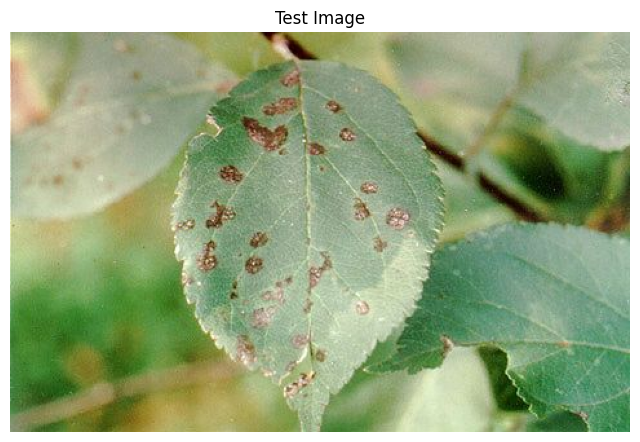

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

IMAGE_PATH = f"{DATA}/applescab.jpg"
test_image = Image.open(IMAGE_PATH).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(test_image)
plt.axis("off")
plt.title("Test Image")
plt.show()

## Image-to-Text (Zero-Shot)

In [5]:
async def run_zero_shot_prediction():
    text_query = "apple leaf with scab disease"
    
    result = await classifier.predict(
        image_input=IMAGE_PATH,
        query_text=text_query,
        top_k=5,
        method="text-to-image"
    )
    
    if result is None:
        print("Error: classifier.predict() returned None")
        print("Check if the classifier.predict() method has a return statement")
        return None
    
    print("Zero-Shot Classification Result")
    print("=" * 60)
    print(f"Query: '{text_query}'")
    print(f"Predicted Label: {result['label']}")
    print(f"Confidence: {result['confidence']:.4f}")
    print(f"\nLabel Scores:")
    for label, score in result['label_scores'].items():
        print(f"  {label}: {score:.4f}")
    print(f"\nTop-{len(result['top_k'])} Results:")
    for i, (label, score) in enumerate(result['top_k'], 1):
        print(f"  {i}. {label}: {score:.4f}")
    
    return result

zero_shot_result = await run_zero_shot_prediction()

Zero-Shot Classification Result
Query: 'apple leaf with scab disease'
Predicted Label: Apple_Scab
Confidence: 0.6761

Label Scores:
  Apple_Scab: 0.6761

Top-5 Results:
  1. Apple_Scab: 0.6761
  2. Apple_Scab: 0.6761
  3. Apple_Scab: 0.6761
  4. Apple_Scab: 0.6761
  5. Apple_Scab: 0.6761


## Image-to-Image (Few-Shot)

In [6]:
async def run_few_shot_prediction():
    result = await classifier.predict(
        image_input=IMAGE_PATH,
        top_k=5,
        method="image-to-image"
    )
    
    print("Few-Shot Classification Result")
    print("=" * 60)
    print(f"Query: Image similarity")
    print(f"Predicted Label: {result['label']}")
    print(f"Confidence: {result['confidence']:.4f}")
    print(f"\nLabel Scores:")
    for label, score in result['label_scores'].items():
        print(f"  {label}: {score:.4f}")
    print(f"\nTop-{len(result['top_k'])} Results:")
    for i, (label, score) in enumerate(result['top_k'], 1):
        print(f"  {i}. {label}: {score:.4f}")
    
    return result

few_shot_result = await run_few_shot_prediction()

Few-Shot Classification Result
Query: Image similarity
Predicted Label: Apple_Scab
Confidence: 0.7479

Label Scores:
  Apple_Scab: 0.7479

Top-5 Results:
  1. Apple_Scab: 0.7616
  2. Apple_Scab: 0.7607
  3. Apple_Scab: 0.7532
  4. Apple_Scab: 0.7334
  5. Apple_Scab: 0.7307


## Image-to-Text Prediction

In [ ]:
async def run_image_to_text_prediction():
    result = await classifier.predict(
        image_input=IMAGE_PATH,
        top_k=5,
        method="image-to-text"
    )
    
    if result is None:
        print("Error: classifier.predict() returned None")
        return None
    
    print("Image-to-Text Classification Result")
    print("=" * 60)
    print(f"Query: Image embedding against text vectors")
    print(f"Predicted Label: {result['label']}")
    print(f"Confidence: {result['confidence']:.4f}")
    print(f"\nLabel Scores:")
    for label, score in result['label_scores'].items():
        print(f"  {label}: {score:.4f}")
    print(f"\nTop-{len(result['top_k'])} Results:")
    for i, (label, score) in enumerate(result['top_k'], 1):
        print(f"  {i}. {label}: {score:.4f}")
    
    return result

image_to_text_result = await run_image_to_text_prediction()

Image-to-Text Classification Result
Query: Image embedding against text vectors
Predicted Label: Apple_Scab
Confidence: 0.7870

Label Scores:
  Apple_Scab: 0.7870

Top-5 Results:
  1. Apple_Scab: 0.7870
  2. Apple_Scab: 0.7870
  3. Apple_Scab: 0.7870
  4. Apple_Scab: 0.7870
  5. Apple_Scab: 0.7870


Method Comparison

Text-to-Image:
  Label: Apple_Scab
  Confidence: 0.6761

Image-to-Image:
  Label: Apple_Scab
  Confidence: 0.7479

Image-to-Text:
  Label: Apple_Scab
  Confidence: 0.7870


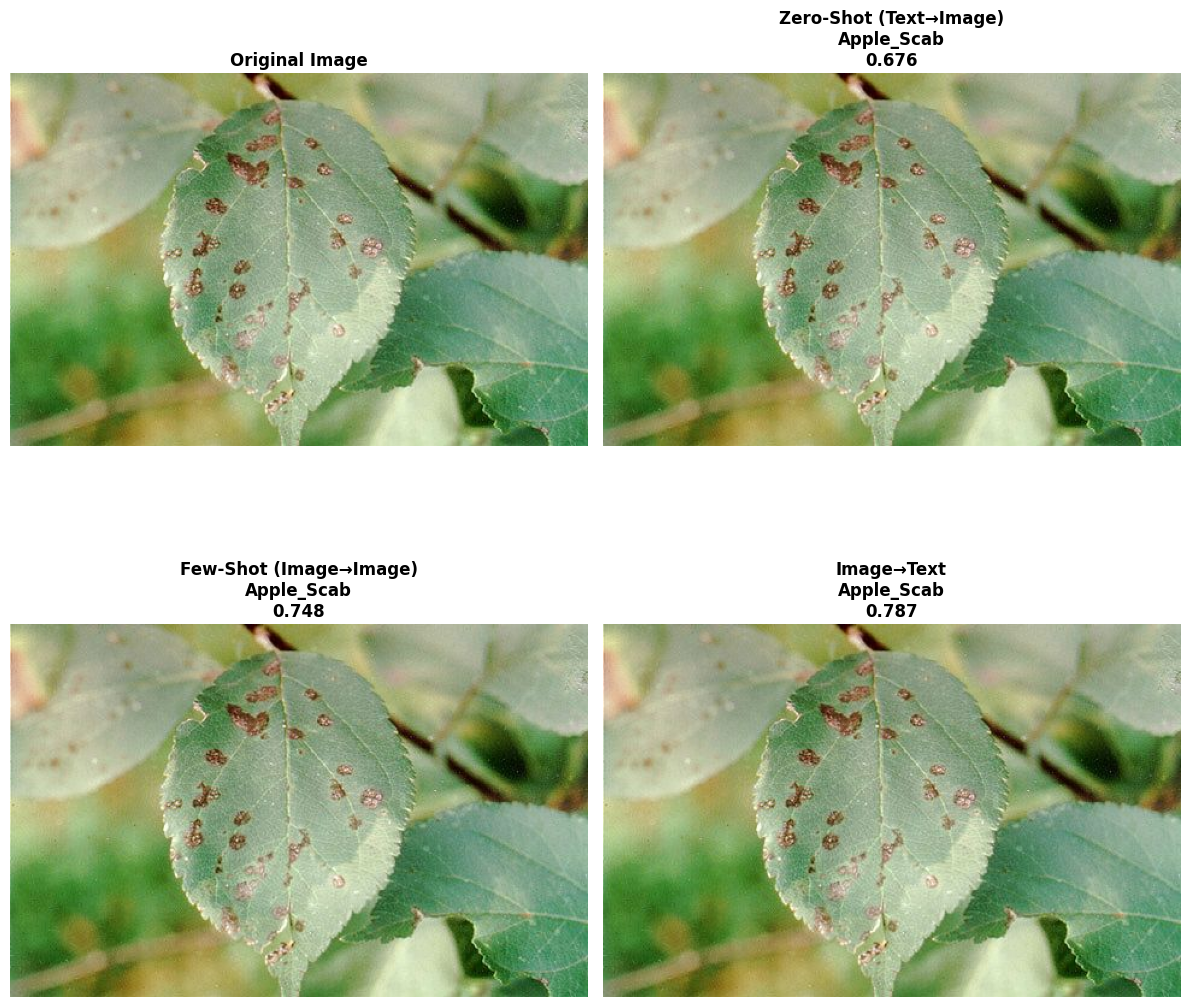

In [8]:
print("Method Comparison")
print("=" * 60)
print(f"\nText-to-Image:")
print(f"  Label: {zero_shot_result['label']}")
print(f"  Confidence: {zero_shot_result['confidence']:.4f}")

print(f"\nImage-to-Image:")
print(f"  Label: {few_shot_result['label']}")
print(f"  Confidence: {few_shot_result['confidence']:.4f}")

print(f"\nImage-to-Text:")
print(f"  Label: {image_to_text_result['label']}")
print(f"  Confidence: {image_to_text_result['confidence']:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(test_image)
axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(test_image)
axes[0, 1].set_title(f"Zero-Shot (Text→Image)\n{zero_shot_result['label']}\n{zero_shot_result['confidence']:.3f}", 
                  fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(test_image)
axes[1, 0].set_title(f"Few-Shot (Image→Image)\n{few_shot_result['label']}\n{few_shot_result['confidence']:.3f}", 
                  fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(test_image)
axes[1, 1].set_title(f"Image→Text\n{image_to_text_result['label']}\n{image_to_text_result['confidence']:.3f}", 
                  fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()